# Bert

In [1]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import  DistilBertForSequenceClassification, DistilBertConfig, get_linear_schedule_with_warmup
from torch.optim import AdamW
import os
from sklearn.model_selection import train_test_split


c:\Text Mining\Text_Mining\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""
ONLY IF YOU USE COLAB:
from google.colab import drive
drive.mount('/content/drive')
"""
checkpoint_dir = "Bert_weights/bert_checkpoints"  # pesi originali (512 token) — NON modificare
checkpoint_dir_256 = "Bert_weights/bert_checkpoints_256token"  # pesi nuovi (256 token)
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(checkpoint_dir_256, exist_ok=True)


In [3]:


file_path = "financial_news_base.jsonl" # "/content/drive/MyDrive/Ds/financial_news_base.jsonl" for colab

df = pd.read_json(file_path, lines=True)


## Data Preprocessing Order: Filter First, Then Subsample

In this notebook we use `max_length=256` tokens for tokenization. It is important to **filter out long sequences BEFORE performing the class-balanced subsampling**, not after.

**Why does the order matter?**

The three sentiment classes (`positive`, `neutral`, `negative`) do not have the same average article length. In financial news datasets, `neutral` articles tend to be shorter (brief factual statements), while `positive` and `negative` articles often contain longer explanations and context.

If we subsample first and filter later:
- We select 8,333 examples per class from the full dataset
- Then we remove articles longer than 256 tokens
- Some classes may lose more examples than others → **the dataset becomes unbalanced again**

If we filter first and subsample later:
- We remove all articles longer than 256 tokens from the full dataset
- Then we sample exactly 8,333 examples per class from the filtered pool
- **All classes remain perfectly balanced by construction**

This ensures that the final training, validation, and test sets are both **length-compatible** with our tokenization limit and **class-balanced**.


In [4]:
from transformers import DistilBertTokenizer as _TempTokenizer

MAX_LEN = 256

# Step 1: Filter rows with more than 256 tokens on the ORIGINAL dataset (before balancing)
_tokenizer_temp = _TempTokenizer.from_pretrained("distilbert-base-uncased")
mask_256 = df["description"].apply(
    lambda t: len(_tokenizer_temp.encode(str(t), add_special_tokens=True)) <= MAX_LEN
)
df_filtered = df[mask_256].reset_index(drop=True)
print(f"Original rows: {len(df)} — After {MAX_LEN} token filter: {len(df_filtered)}")
print("\nClass distribution after filtering:")
print(df_filtered["sentiment_label"].value_counts())

# Step 2: Balance classes AFTER filtering
target_per_class = 25000 // 3

dfs = []
for label in df_filtered["sentiment_label"].unique():
    subset = df_filtered[df_filtered["sentiment_label"] == label]
    dfs.append(subset.sample(n=target_per_class, random_state=100))

df_balanced = pd.concat(dfs).sample(frac=1, random_state=100).reset_index(drop=True)
print(f"\nBalanced dataset size: {len(df_balanced)}")
print(df_balanced["sentiment_label"].value_counts())


Token indices sequence length is longer than the specified maximum sequence length for this model (1534 > 512). Running this sequence through the model will result in indexing errors


Original rows: 70547 — After 256 token filter: 67111

Class distribution after filtering:
sentiment_label
positive    36819
neutral     18666
negative    11626
Name: count, dtype: int64

Balanced dataset size: 24999
sentiment_label
negative    8333
positive    8333
neutral     8333
Name: count, dtype: int64


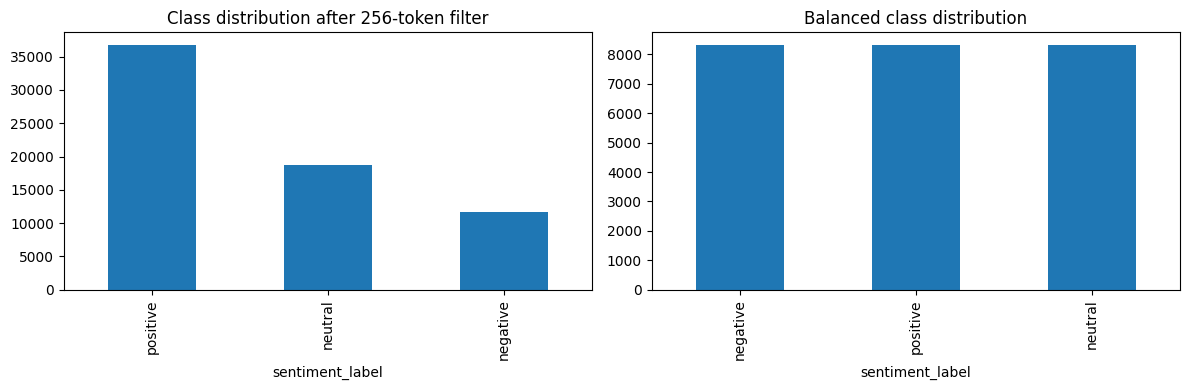

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_filtered["sentiment_label"].value_counts().plot(kind="bar", ax=axes[0], title="Class distribution after 256-token filter")
df_balanced["sentiment_label"].value_counts().plot(kind="bar", ax=axes[1], title="Balanced class distribution")

plt.tight_layout()
plt.show()


In [6]:
df_bert = df_balanced[["description", "sentiment_label"]]


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [8]:
X = df_bert["description"]
y = df_bert["sentiment_label"].map({"positive": 0, "negative": 1, "neutral": 2}).astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=100)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=100)

print(X_train.shape, X_val.shape, X_test.shape)
y_train.head()


(17499,) (3750,) (3750,)


15970    1
14574    1
21395    0
2037     2
19629    1
Name: sentiment_label, dtype: int64

In [9]:
from transformers import DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_tokenized = tokenizer(
    X_train.tolist(),
    padding="max_length",
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

val_tokenized = tokenizer(
    X_val.tolist(),
    padding="max_length",
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

test_tokenized = tokenizer(
    X_test.tolist(),
    padding="max_length",
    truncation=True,
    max_length=256,
    return_tensors="pt"
)


In [10]:
y_train_tensor = torch.tensor(y_train.values)
y_val_tensor = torch.tensor(y_val.values)
y_test_tensor = torch.tensor(y_test.values)

In [11]:
class Dataset(torch.utils.data.Dataset):
  def __init__(self,tokens, labels):
    self.tokens = tokens
    self.labels = labels

  def __getitem__(self, idx):
      item = {key: val[idx] for key, val in self.tokens.items()}
      item["labels"] = self.labels[idx]
      return item

  def __len__(self):
      return len(self.labels)

In [12]:
#train_dataset = Dataset(train_tokenized, y_train_tensor)
#val_dataset = Dataset(val_tokenized, y_val_tensor)
#test_dataset = Dataset(test_tokenized, y_test_tensor)


#train_loader = DataLoader(train_dataset, batch_size = 16)
#val_loader = DataLoader(val_dataset, batch_size = 16)
#test_loader = DataLoader(test_dataset, batch_size = 16)

In [13]:
import time
from tqdm import tqdm


def train_epoch(model ,dataloader, optimizer, scheduler, device):
  model.train()
  total_loss = 0

  for batch in tqdm(dataloader, desc = "Training"):
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    optimizer.zero_grad()

        # Forward pass: compute model predictions and loss
        # BertForSequenceClassification automatically computes loss when labels are provided
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss

        # Backward pass: compute gradients
    loss.backward()

        # Update weights based on gradients
    optimizer.step()

    scheduler.step()

    total_loss += loss.item()

  return total_loss / len(dataloader)

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
    return total_loss / len(dataloader)

# NEXT CELL: TRAIN FOR GPU

In [14]:
batch_size = 32          
lr = 5e-6
warmup_ratio = 0.1

best_val_loss = float('inf')
train_losses = []
val_losses = []
train_loader = DataLoader(Dataset(train_tokenized, y_train_tensor), batch_size=batch_size)
val_loader = DataLoader(Dataset(val_tokenized, y_val_tensor), batch_size=batch_size)

config_finetune = DistilBertConfig.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3,
    output_attentions=True,
    dropout=0.3,
    attention_dropout=0.15
)
model_finetune = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", config=config_finetune)

model_finetune.to(device)

optimizer = AdamW(model_finetune.parameters(), lr=lr, weight_decay=0.05)
epochs = 5
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(warmup_ratio * total_steps),
    num_training_steps=total_steps)

patience = 2
min_delta = 0.01
patience_counter = 0
best_val_loss = float('inf')
best_epoch = -1
# ⚠️ Salva in checkpoint_dir_256 — NON sovrascrive i pesi originali
best_ckpt_path = os.path.join(checkpoint_dir_256, "bert_best_model_256token.pt")

for epoch in range(epochs):
    print(f"\n Epoch {epoch + 1}/{epochs}")
    train_loss = train_epoch(model_finetune, train_loader, optimizer, scheduler, device)
    val_loss = eval_epoch(model_finetune, val_loader, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1} — Training loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}")

    improved = val_loss < best_val_loss * (1 - min_delta)

    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model_finetune.state_dict(), best_ckpt_path)
        print(f"New best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\n Early stopping triggered. Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6684.15it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Epoch 1/5


Validation: 100%|██████████| 118/118 [00:15<00:00,  7.47it/s]


Epoch 1 — Training loss: 0.9867, Validation loss: 0.8484
New best model saved (val_loss=0.8484)

 Epoch 2/5


Validation: 100%|██████████| 118/118 [00:15<00:00,  7.39it/s]


...

Epoch 3 — Training loss: 0.7914, Validation loss: 0.8043
New best model saved (val_loss=0.8043)

 Epoch 4/5


Validation: 100%|██████████| 118/118 [00:17<00:00,  6.78it/s]


Epoch 4 — Training loss: 0.7657, Validation loss: 0.8036
No improvement. Patience: 1/2

 Epoch 5/5


Validation: 100%|██████████| 118/118 [00:16<00:00,  7.22it/s]

Epoch 5 — Training loss: 0.7549, Validation loss: 0.8032
No improvement. Patience: 2/2

 Early stopping triggered. Best epoch: 3, Best val loss: 0.8043

✅ Training complete. Best epoch: 3, Best val loss: 0.8043


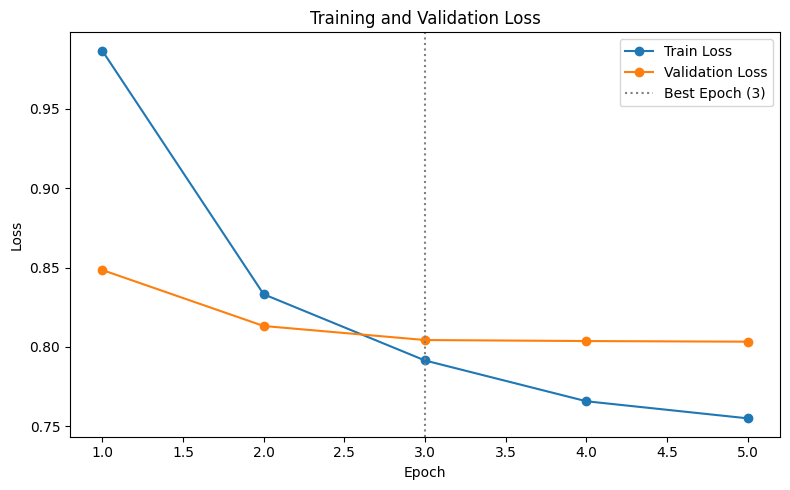

In [15]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses,   marker='o', label='Validation Loss')
plt.axvline(x=best_epoch, color='gray', linestyle=':', label=f'Best Epoch ({best_epoch})')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()


 Classification Report:
              precision    recall  f1-score   support

    positive       0.65      0.59      0.62      1259
    negative       0.66      0.68      0.67      1241
     neutral       0.64      0.68      0.66      1250

    accuracy                           0.65      3750
   macro avg       0.65      0.65      0.65      3750
weighted avg       0.65      0.65      0.65      3750

Confusion Matrix:


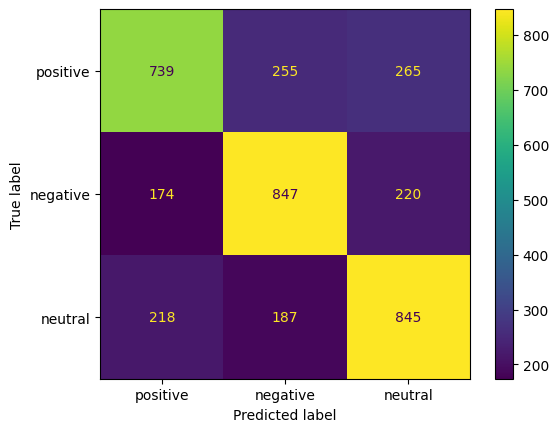

In [16]:
model_finetune.load_state_dict(torch.load(best_ckpt_path, map_location=device))
model_finetune.to(device)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

test_loader = DataLoader(Dataset(test_tokenized, y_test_tensor), batch_size=batch_size)

model_finetune.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model_finetune(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

label_names = ['positive', 'negative', 'neutral']
print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names))
print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot()
plt.show()


# FinBert

In [13]:
# FinBERT — tokenizzazione con max_length=256
from transformers import BertTokenizer, BertForSequenceClassification

finbert_tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")

train_tokenized_fb = finbert_tokenizer(X_train.tolist(), padding="max_length", truncation=True, max_length=256, return_tensors="pt")
val_tokenized_fb   = finbert_tokenizer(X_val.tolist(),   padding="max_length", truncation=True, max_length=256, return_tensors="pt")
test_tokenized_fb  = finbert_tokenizer(X_test.tolist(),  padding="max_length", truncation=True, max_length=256, return_tensors="pt")


In [14]:
finbert = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")

# Congela tutti i parametri
for param in finbert.parameters():
    param.requires_grad = False

# Scongela solo il classification head
for param in finbert.classifier.parameters():
    param.requires_grad = True

print(finbert.config.id2label)  # <-- guarda l'output di questa riga

finbert.to(device)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 27743.03it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{0: 'positive', 1: 'negative', 2: 'neutral'}


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [15]:
batch_size   = 32
lr           = 2e-4
warmup_ratio = 0.1

train_losses_fb = []
val_losses_fb   = []

train_loader_fb = DataLoader(Dataset(train_tokenized_fb, y_train_tensor), batch_size=batch_size)
val_loader_fb   = DataLoader(Dataset(val_tokenized_fb,   y_val_tensor),   batch_size=batch_size)

optimizer_fb = AdamW(filter(lambda p: p.requires_grad, finbert.parameters()), lr=lr, weight_decay=0.01)
epochs       = 5
total_steps  = len(train_loader_fb) * epochs
scheduler_fb = get_linear_schedule_with_warmup(optimizer_fb, num_warmup_steps=int(warmup_ratio * total_steps), num_training_steps=total_steps)

patience         = 2
min_delta        = 0.01
patience_counter = 0
best_val_loss_fb = float('inf')
best_epoch_fb    = -1
# Salva in checkpoint_dir_256 — NON sovrascrive i pesi originali
best_ckpt_fb = os.path.join(checkpoint_dir_256, "finbert_best_model_256token.pt")

for epoch in range(epochs):
    print(f"\n Epoch {epoch + 1}/{epochs}")
    train_loss = train_epoch(finbert, train_loader_fb, optimizer_fb, scheduler_fb, device)
    val_loss   = eval_epoch(finbert, val_loader_fb, device)
    train_losses_fb.append(train_loss)
    val_losses_fb.append(val_loss)
    print(f"Epoch {epoch+1} — Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

    if val_loss < best_val_loss_fb * (1 - min_delta):
        best_val_loss_fb = val_loss
        best_epoch_fb    = epoch + 1
        patience_counter = 0
        torch.save(finbert.state_dict(), best_ckpt_fb)
        print(f"New best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\n Early stopping. Best epoch: {best_epoch_fb}, Best val loss: {best_val_loss_fb:.4f}")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch_fb}, Best val loss: {best_val_loss_fb:.4f}")



 Epoch 1/5


Validation: 100%|██████████| 118/118 [00:27<00:00,  4.34it/s]


Epoch 1 — Train loss: 0.9718, Val loss: 0.9117
New best model saved (val_loss=0.9117)

 Epoch 2/5


Validation: 100%|██████████| 118/118 [00:27<00:00,  4.32it/s]


Epoch 2 — Train loss: 0.9057, Val loss: 0.8989
New best model saved (val_loss=0.8989)

 Epoch 3/5


Validation: 100%|██████████| 118/118 [00:27<00:00,  4.24it/s]


Epoch 3 — Train loss: 0.9019, Val loss: 0.8933
No improvement. Patience: 1/2

 Epoch 4/5


Validation: 100%|██████████| 118/118 [00:27<00:00,  4.25it/s]

Epoch 4 — Train loss: 0.8966, Val loss: 0.8922
No improvement. Patience: 2/2

 Early stopping. Best epoch: 2, Best val loss: 0.8989

✅ Training complete. Best epoch: 2, Best val loss: 0.8989


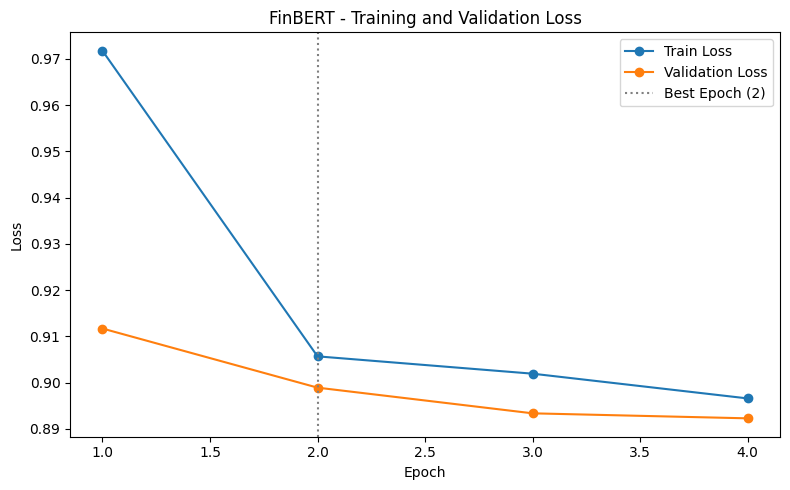

In [16]:
epochs_range = range(1, len(train_losses_fb) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses_fb, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses_fb,   marker='o', label='Validation Loss')
plt.axvline(x=best_epoch_fb, color='gray', linestyle=':', label=f'Best Epoch ({best_epoch_fb})')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('FinBERT - Training and Validation Loss')
plt.legend(); plt.tight_layout(); plt.show()


 Classification Report — FinBERT:
              precision    recall  f1-score   support

    positive       0.62      0.48      0.54      1259
    negative       0.63      0.60      0.62      1241
     neutral       0.52      0.66      0.59      1250

    accuracy                           0.58      3750
   macro avg       0.59      0.58      0.58      3750
weighted avg       0.59      0.58      0.58      3750

Confusion Matrix:


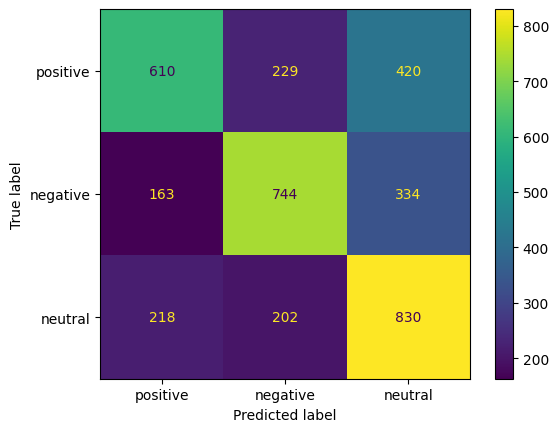

In [17]:
finbert.load_state_dict(torch.load(best_ckpt_fb, map_location=device))
finbert.to(device)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

test_loader_fb = DataLoader(Dataset(test_tokenized_fb, y_test_tensor), batch_size=batch_size)

finbert.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader_fb:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = finbert(input_ids=input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

label_names = ['positive', 'negative', 'neutral']
print("\n Classification Report — FinBERT:")
print(classification_report(all_labels, all_preds, target_names=label_names))
print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot()
plt.show()


# BERT Base

Fine-tuning of `bert-base-uncased` with `max_length=256`. Weights are saved in `checkpoint_dir_256`.
BERT base has 12 transformer layers and ~110M parameters, compared to DistilBERT's 6 layers and ~66M parameters.
It is expected to achieve higher accuracy at the cost of slower training.


In [14]:
# BERT Base — tokenizzazione con max_length=256
from transformers import BertTokenizer, BertForSequenceClassification, BertConfig

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_tokenized_bert = bert_tokenizer(X_train.tolist(), padding="max_length", truncation=True, max_length=256, return_tensors="pt")
val_tokenized_bert   = bert_tokenizer(X_val.tolist(),   padding="max_length", truncation=True, max_length=256, return_tensors="pt")
test_tokenized_bert  = bert_tokenizer(X_test.tolist(),  padding="max_length", truncation=True, max_length=256, return_tensors="pt")


In [15]:
# BERT Base — carica modello
config_bert = BertConfig.from_pretrained(
    "bert-base-uncased",
    num_labels=3,
    output_attentions=True
)
model_bert = BertForSequenceClassification.from_pretrained("bert-base-uncased", config=config_bert)
model_bert.to(device)
print("BERT base loaded")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8250.14it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

BERT base loaded


In [16]:
# BERT Base — training
batch_size_bert = 32
lr_bert         = 2e-5
warmup_ratio    = 0.1

train_losses_bert = []
val_losses_bert   = []

train_loader_bert = DataLoader(Dataset(train_tokenized_bert, y_train_tensor), batch_size=batch_size_bert)
val_loader_bert   = DataLoader(Dataset(val_tokenized_bert,   y_val_tensor),   batch_size=batch_size_bert)

optimizer_bert = AdamW(model_bert.parameters(), lr=lr_bert, weight_decay=0.01)
epochs_bert    = 3
total_steps    = len(train_loader_bert) * epochs_bert
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=int(warmup_ratio * total_steps),
    num_training_steps=total_steps
)

patience         = 2
min_delta        = 0.01
patience_counter = 0
best_val_loss_bert = float('inf')
best_epoch_bert    = -1
# Salva in checkpoint_dir_256 — NON sovrascrive i pesi originali
best_ckpt_bert = os.path.join(checkpoint_dir_256, "bert_base_best_model_256token.pt")

for epoch in range(epochs_bert):
    print(f"\n Epoch {epoch + 1}/{epochs_bert}")
    train_loss = train_epoch(model_bert, train_loader_bert, optimizer_bert, scheduler_bert, device)
    val_loss   = eval_epoch(model_bert, val_loader_bert, device)
    train_losses_bert.append(train_loss)
    val_losses_bert.append(val_loss)
    print(f"Epoch {epoch+1} — Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

    if val_loss < best_val_loss_bert * (1 - min_delta):
        best_val_loss_bert = val_loss
        best_epoch_bert    = epoch + 1
        patience_counter   = 0
        torch.save(model_bert.state_dict(), best_ckpt_bert)
        print(f"New best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\n Early stopping. Best epoch: {best_epoch_bert}, Best val loss: {best_val_loss_bert:.4f}")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch_bert}, Best val loss: {best_val_loss_bert:.4f}")



 Epoch 1/3


Validation: 100%|██████████| 118/118 [00:39<00:00,  3.02it/s]


Epoch 1 — Train loss: 0.8814, Val loss: 0.7791
New best model saved (val_loss=0.7791)

 Epoch 2/3


Validation: 100%|██████████| 118/118 [00:39<00:00,  2.99it/s]


Epoch 2 — Train loss: 0.6740, Val loss: 0.7798
No improvement. Patience: 1/2

 Epoch 3/3


Validation: 100%|██████████| 118/118 [00:39<00:00,  2.99it/s]

Epoch 3 — Train loss: 0.5314, Val loss: 0.8343
No improvement. Patience: 2/2

 Early stopping. Best epoch: 1, Best val loss: 0.7791

✅ Training complete. Best epoch: 1, Best val loss: 0.7791


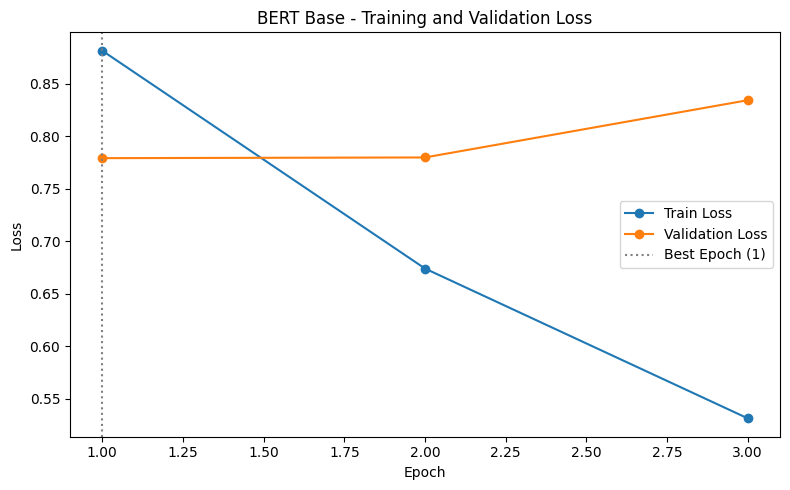

In [17]:
epochs_range = range(1, len(train_losses_bert) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses_bert, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses_bert,   marker='o', label='Validation Loss')
plt.axvline(x=best_epoch_bert, color='gray', linestyle=':', label=f'Best Epoch ({best_epoch_bert})')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('BERT Base - Training and Validation Loss')
plt.legend(); plt.tight_layout(); plt.show()



 Classification Report — BERT Base:
              precision    recall  f1-score   support

    positive       0.66      0.61      0.64      1259
    negative       0.66      0.69      0.67      1241
     neutral       0.66      0.68      0.67      1250

    accuracy                           0.66      3750
   macro avg       0.66      0.66      0.66      3750
weighted avg       0.66      0.66      0.66      3750

Confusion Matrix:


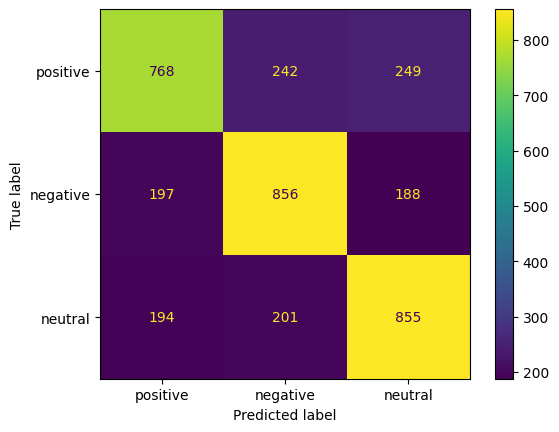

In [18]:
model_bert.load_state_dict(torch.load(best_ckpt_bert, map_location=device))
model_bert.to(device)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

test_loader_bert = DataLoader(Dataset(test_tokenized_bert, y_test_tensor), batch_size=batch_size_bert)

model_bert.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader_bert:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

label_names = ['positive', 'negative', 'neutral']
print("\n Classification Report — BERT Base:")
print(classification_report(all_labels, all_preds, target_names=label_names))
print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot()
plt.show()
